In [1]:
import os
import yaml
import copy
import time
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from scipy.stats import t as student_t  # <-- define at module scope

def corr_pvalue(da_x: xr.DataArray, da_y: xr.DataArray, dim: str):
    r = xr.corr(da_x, da_y, dim=dim)

    n = xr.where(np.isfinite(da_x) & np.isfinite(da_y), 1, 0).sum(dim)
    df = n - 2

    denom = xr.where((1.0 - r**2) > 0, (1.0 - r**2), np.nan)

    tstat = r * xr.apply_ufunc(
        np.sqrt,
        df / denom,
        dask="parallelized",
        output_dtypes=[np.float64],
    )

    # use a top-level function (no missing 'stats' inside workers)
    def pval_func(tstat_np, df_np):
        return 2.0 * student_t.sf(np.abs(tstat_np), df_np)

    p = xr.apply_ufunc(
        pval_func,
        tstat, df,
        dask="parallelized",
        output_dtypes=[np.float64],
    ).where(df > 0)

    return r, p

## Inter-annual

### Default

In [4]:
save_dir = f'/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/'

In [9]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax.zarr'
ds_ERA5 = xr.open_zarr(fn)

fn_detrend = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_detrend.zarr'
ds_ERA5_detrend = xr.open_zarr(fn_detrend)

ds_target = xr.merge([ds_ERA5, ds_ERA5_detrend])
# dim = (year: 68, lat: 192, lon: 288)
# print(list(ds_target.keys()))
# ['PRECT_max', 'PRECT_mean', 'TREFHTMX_max', 'TREFHT_mean', 'PRECT_max_detrend', 'PRECT_mean_detrend', 'TREFHTMX_max_detrend', 'TREFHT_mean_detrend']

fn_CESM = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/SMYLE_Annual_Metrics.zarr'
ds_CESM = xr.open_zarr(fn_CESM)
# dims = (lead_year: 10, lat: 192, lon: 288, valid_year: 53, member: 20)
# print(list(ds_CESM.keys()))
# ['PRECT_max_intercept', 'PRECT_max_mean_detrended', 'PRECT_max_mean_raw', 
# 'PRECT_max_member_detrended', 'PRECT_max_member_raw', 'PRECT_max_slope', 
# 'PRECT_mean_intercept', 'PRECT_mean_mean_detrended', 'PRECT_mean_mean_raw', 
# 'PRECT_mean_member_detrended', 'PRECT_mean_member_raw', 'PRECT_mean_slope', 
# 'TREFHTMX_max_intercept', 'TREFHTMX_max_mean_detrended', 'TREFHTMX_max_mean_raw', 
# 'TREFHTMX_max_member_detrended', 'TREFHTMX_max_member_raw', 'TREFHTMX_max_slope', 
# 'TREFHT_mean_intercept', 'TREFHT_mean_mean_detrended', 'TREFHT_mean_mean_raw', 
# 'TREFHT_mean_member_detrended', 'TREFHT_mean_member_raw', 'TREFHT_mean_slope']

In [19]:
# ============================================================
# Align coordinates
# ============================================================
# ds_target uses 'year', ds_CESM uses 'valid_year'. Rename and intersect.
ds_target = ds_target.rename({"year": "valid_year"})

common_years = np.intersect1d(ds_target.valid_year, ds_CESM.valid_year)
ds_target = ds_target.sel(valid_year=common_years)
ds_CESM   = ds_CESM.sel(valid_year=common_years)

In [22]:
# ============================================================
# Metric functions
# ============================================================

def acc(forecast, obs, dim="valid_year"):
    """
    Anomaly correlation coefficient between forecast and obs along `dim`.
    Both inputs should already be anomalies (raw-vs-raw or detrended-vs-detrended).
    """
    f_mean = forecast.mean(dim, skipna=True)
    o_mean = obs.mean(dim, skipna=True)
    f_anom = forecast - f_mean
    o_anom = obs - o_mean

    num = (f_anom * o_anom).sum(dim, skipna=True)
    den = np.sqrt(
        (f_anom ** 2).sum(dim, skipna=True) * (o_anom ** 2).sum(dim, skipna=True)
    )
    return num / den


def rmse(forecast, obs, dim="valid_year"):
    """Root-mean-square error along `dim`."""
    return np.sqrt(((forecast - obs) ** 2).mean(dim, skipna=True))


def crps_ensemble(forecast, obs, member_dim="member", time_dim="valid_year", fair=True):
    """
    Fair CRPS for a finite ensemble using the kernel representation.

    CRPS(F, o) = mean_i |x_i - o| - 0.5 * mean_{i,j} |x_i - x_j|

    The 'fair' version replaces 1/N^2 with 1/(N(N-1)) in the second term to
    correct for the finite-ensemble bias. Returns CRPS averaged over time_dim.

    Parameters
    ----------
    forecast : DataArray with member_dim and time_dim
    obs      : DataArray with time_dim (no member_dim)
    """
    N = forecast.sizes[member_dim]

    # Term 1: mean absolute error between members and obs
    term1 = np.abs(forecast - obs).mean(member_dim, skipna=True)

    # Term 2: mean absolute pairwise difference between members
    # Rename one copy so the two member dims don't collapse
    f_i = forecast
    f_j = forecast.rename({member_dim: member_dim + "_j"})
    pairwise = np.abs(f_i - f_j)

    if fair:
        # Sum then divide by N*(N-1); diagonal is zero so it doesn't matter
        term2 = 0.5 * pairwise.sum(
            dim=[member_dim, member_dim + "_j"], skipna=True
        ) / (N * (N - 1))
    else:
        term2 = 0.5 * pairwise.mean(
            dim=[member_dim, member_dim + "_j"], skipna=True
        )

    crps_per_time = term1 - term2
    return crps_per_time.mean(time_dim, skipna=True)


In [23]:
# ============================================================
# Variable pairings
# ============================================================
# Map each base variable to its (CESM prefix, ERA5 name)
variables = {
    "PRECT_max":    "PRECT_max",
    "PRECT_mean":   "PRECT_mean",
    "TREFHTMX_max": "TREFHTMX_max",
    "TREFHT_mean":  "TREFHT_mean",
}


# ============================================================
# Compute metrics
# ============================================================

ds_skill = xr.Dataset()

for var, era5_var in variables.items():

    # ----- raw versions -----
    obs_raw   = ds_target[era5_var]                          # (valid_year, lat, lon)
    fmean_raw = ds_CESM[f"{var}_mean_raw"]                   # (valid_year, lead_year, lat, lon)
    fmem_raw  = ds_CESM[f"{var}_member_raw"]                 # (valid_year, lead_year, member, lat, lon)

    ds_skill[f"{var}_ACC_raw"]  = acc(fmean_raw, obs_raw)
    ds_skill[f"{var}_RMSE_raw"] = rmse(fmean_raw, obs_raw)
    ds_skill[f"{var}_CRPS_raw"] = crps_ensemble(fmem_raw, obs_raw)

    # ----- detrended versions -----
    obs_det   = ds_target[f"{era5_var}_detrend"]
    fmean_det = ds_CESM[f"{var}_mean_detrended"]
    fmem_det  = ds_CESM[f"{var}_member_detrended"]

    ds_skill[f"{var}_ACC_detrend"]  = acc(fmean_det, obs_det)
    ds_skill[f"{var}_RMSE_detrend"] = rmse(fmean_det, obs_det)
    ds_skill[f"{var}_CRPS_detrend"] = crps_ensemble(fmem_det, obs_det)


# ============================================================
# Add CRPSS against climatology as a unitless skill score
# ============================================================
# CRPS of climatological forecast = MAE of obs about its own median
# Use the obs distribution itself as the reference forecast.

def crps_climatology(obs, time_dim="valid_year"):
    """
    CRPS of a climatological forecast (full obs distribution as the predictive
    distribution) computed per gridpoint, then averaged over time_dim.
    Equivalent to mean_i mean_j |o_i - o_j| / 2 minus mean_i |o_i - mean_j o_j|,
    but the kernel form on the obs treated as 'members' gives the same thing.
    """
    o_i = obs
    o_j = obs.rename({time_dim: time_dim + "_j"})
    pairwise = np.abs(o_i - o_j)
    N = obs.sizes[time_dim]
    # CRPS of empirical distribution against itself, averaged
    # E|X - X'| / 2 where X, X' iid from obs
    return 0.5 * pairwise.sum(
        dim=[time_dim, time_dim + "_j"], skipna=True
    ) / (N * (N - 1))


for var, era5_var in variables.items():
    crps_clim_raw = crps_climatology(ds_target[era5_var])
    crps_clim_det = crps_climatology(ds_target[f"{era5_var}_detrend"])

    ds_skill[f"{var}_CRPSS_raw"] = 1 - ds_skill[f"{var}_CRPS_raw"]  / crps_clim_raw
    ds_skill[f"{var}_CRPSS_detrend"] = 1 - ds_skill[f"{var}_CRPS_detrend"] / crps_clim_det


In [26]:
fn_save = save_dir + 'SMYLE_Verif.zarr'
# ds_skill.to_zarr(fn_save, mode='w')

In [22]:
ds_skill = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/SMYLE_Verif.zarr')
Test = ds_skill['TREFHT_mean_ACC_raw'].values

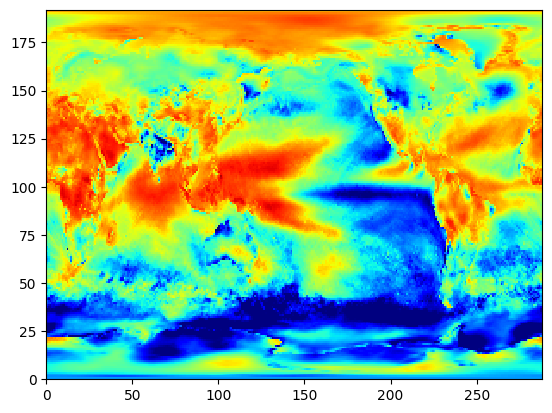

In [29]:
plt.pcolormesh(Test[-1, ...], vmin=0, vmax=1, cmap=plt.cm.jet)

In [24]:
Test_old = ds_ACC_all['TREFHT_mean'].values

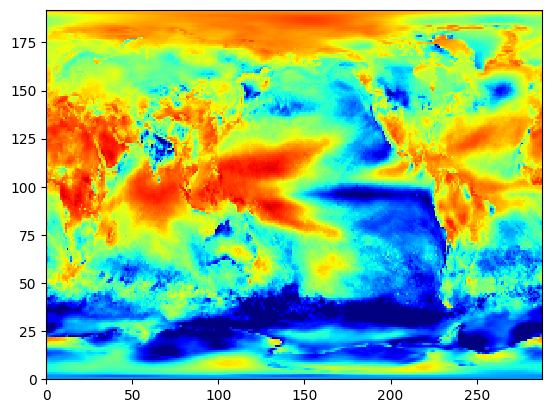

In [28]:
plt.pcolormesh(Test_old[-1, ...], vmin=0, vmax=1, cmap=plt.cm.jet)

In [11]:
Test.shape

(10, 192, 288)

In [26]:
ds_skill_old = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_ACC.zarr')
Test_old2 = ds_skill_old['TREFHT_mean'].values

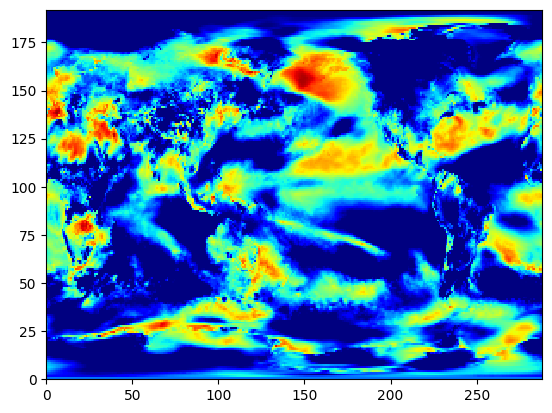

In [27]:
plt.pcolormesh(Test_old2[1, ...], vmin=0, vmax=1, cmap=plt.cm.jet)

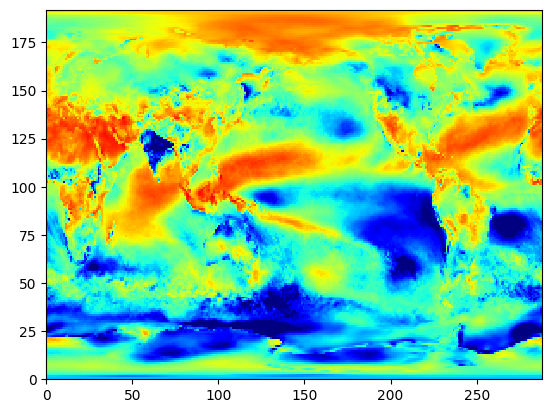

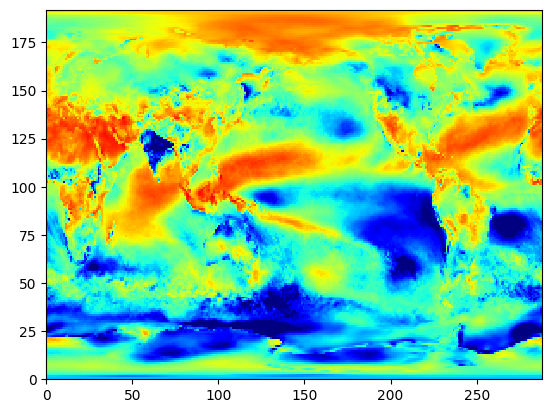

In [17]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_all = xr.concat(ds_collection, dim='lead_year')

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Text(0.5, 0.98, 'PRECT_max (annual maximum daily precipitation) — raw')

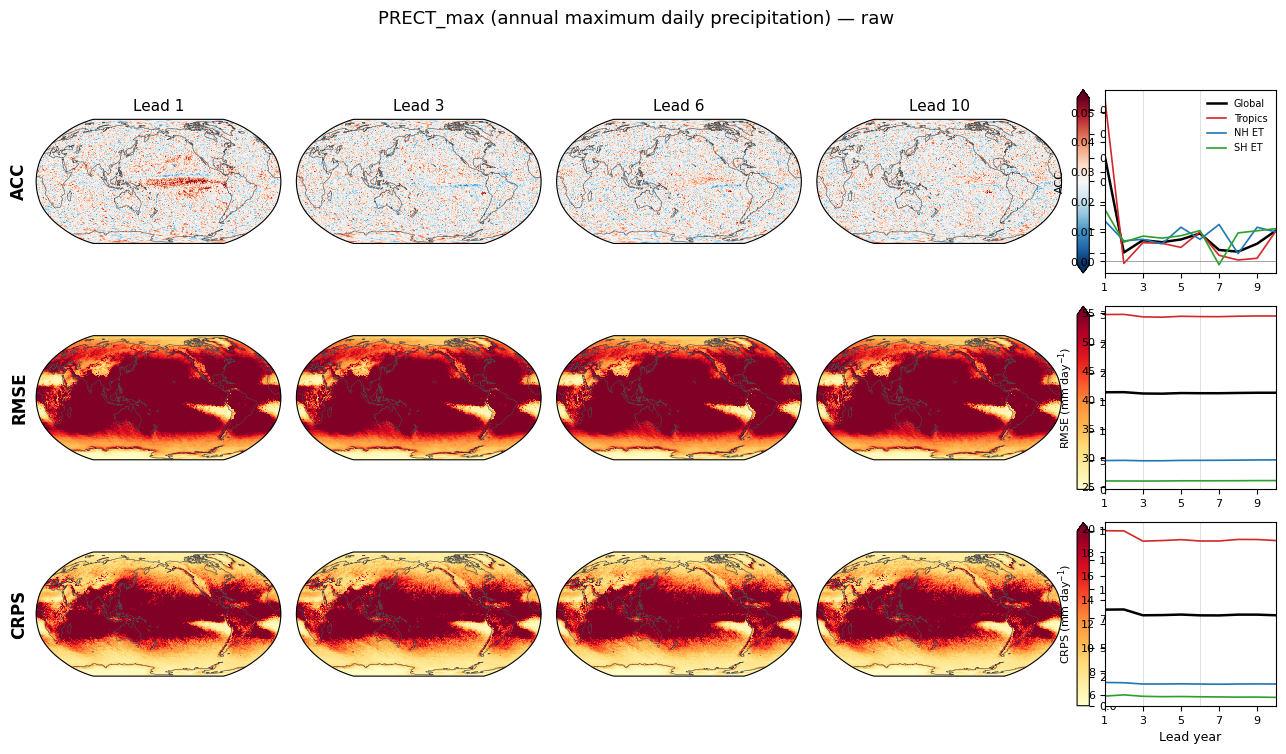

In [32]:
var_plot = ['PRECT_max_ACC_raw', 'PRECT_max_RMSE_raw', 'PRECT_max_CRPS_raw']
leads_to_show = [0, 2, 5, 9]

# Per-metric colormap and limits
metric_settings = {
    'ACC':  {'cmap': 'RdBu_r', 'vmin': -0.7, 'vmax': 0.7,
             'label': 'ACC', 'extend': 'both'},
    'RMSE': {'cmap': 'YlOrRd', 'vmin': 0,    'vmax': 30,
             'label': 'RMSE (mm day$^{-1}$)', 'extend': 'max'},
    'CRPS': {'cmap': 'YlOrRd', 'vmin': 0,    'vmax': 15,
             'label': 'CRPS (mm day$^{-1}$)', 'extend': 'max'},
}

# Latitude weights for area-mean curves
weights = np.cos(np.deg2rad(ds_skill.lat))

# ---- Figure layout ----
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(
    nrows=3, ncols=6,
    width_ratios=[1, 1, 1, 1, 0.05, 0.7],   # 4 maps, colorbar slot, curve
    wspace=0.08, hspace=0.18,
)

proj = ccrs.Robinson(central_longitude=180)
data_proj = ccrs.PlateCarree()

for row, varname in enumerate(var_plot):
    metric_key = varname.split('_')[2]   # 'ACC', 'RMSE', or 'CRPS'
    cfg = metric_settings[metric_key]
    da = ds_skill[varname]               # dims: (lead_year, lat, lon)

    # ----- Maps for selected leads -----
    for col, lead in enumerate(leads_to_show):
        ax = fig.add_subplot(gs[row, col], projection=proj)
        field = da.sel(lead_year=lead)

        im = ax.pcolormesh(
            field.lon, field.lat, field.values,
            transform=data_proj,
            cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'],
            shading='auto',
        )
        ax.coastlines(linewidth=0.4, color='0.3')
        ax.set_global()

        if row == 0:
            ax.set_title(f'Lead {lead + 1}', fontsize=11)
        if col == 0:
            ax.text(-0.07, 0.5, metric_key,
                    transform=ax.transAxes,
                    rotation=90, va='center', ha='center',
                    fontsize=12, fontweight='bold')

    # ----- Colorbar for this row -----
    cax = fig.add_subplot(gs[row, 4])
    cb = fig.colorbar(im, cax=cax, extend=cfg['extend'])
    cb.set_label(cfg['label'], fontsize=9)
    cb.ax.tick_params(labelsize=8)

    # ----- Lead-time curve (area-weighted means) -----
    ax_curve = fig.add_subplot(gs[row, 5])

    # Global, land-only, ocean-only would need a mask;
    # here split by latitude band as a simple proxy.
    tropics = da.sel(lat=slice(-30, 30)).weighted(
        weights.sel(lat=slice(-30, 30))
    ).mean(['lat', 'lon'])
    extratropics_n = da.sel(lat=slice(30, 90)).weighted(
        weights.sel(lat=slice(30, 90))
    ).mean(['lat', 'lon'])
    extratropics_s = da.sel(lat=slice(-90, -30)).weighted(
        weights.sel(lat=slice(-90, -30))
    ).mean(['lat', 'lon'])
    glob = da.weighted(weights).mean(['lat', 'lon'])

    leads_axis = np.arange(1, da.sizes['lead_year'] + 1)
    ax_curve.plot(leads_axis, glob,           '-', color='black', lw=1.8, label='Global')
    ax_curve.plot(leads_axis, tropics,        '-', color='C3',    lw=1.2, label='Tropics')
    ax_curve.plot(leads_axis, extratropics_n, '-', color='C0',    lw=1.2, label='NH ET')
    ax_curve.plot(leads_axis, extratropics_s, '-', color='C2',    lw=1.2, label='SH ET')

    # Mark the leads shown as maps
    for lead in leads_to_show:
        ax_curve.axvline(lead + 1, color='0.85', lw=0.6, zorder=0)

    if metric_key == 'ACC':
        ax_curve.axhline(0, color='0.5', lw=0.5)
    ax_curve.set_xlim(1, da.sizes['lead_year'])
    ax_curve.set_xticks([1, 3, 5, 7, 9])
    ax_curve.tick_params(labelsize=8)
    ax_curve.set_ylabel(cfg['label'], fontsize=8)
    if row == 2:
        ax_curve.set_xlabel('Lead year', fontsize=9)
    if row == 0:
        ax_curve.legend(fontsize=7, frameon=False, loc='best')

fig.suptitle('PRECT_max (annual maximum daily precipitation) — raw',
             fontsize=13, y=0.98)

In [7]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_all = xr.concat(ds_collection, dim='lead_year')

In [8]:
ds_ACC_all = ds_ACC_all.load()

In [9]:
save_name = save_dir + 'CESM_minmax_ACC.zarr'
ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_ACC.zarr


In [10]:
ds_ACC_all

<xarray.Dataset> Size: 27MB
Dimensions:            (lead_year: 10, lat: 192, lon: 288)
Coordinates:
  * lead_year          (lead_year) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lat                (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    PRECT_max          (lead_year, lat, lon) float32 2MB 0.1416 ... 0.2023
    PRECT_max_pval     (lead_year, lat, lon) float64 4MB 0.6963 ... 0.5752
    PRECT_mean         (lead_year, lat, lon) float32 2MB 0.2215 ... -0.2628
    PRECT_mean_pval    (lead_year, lat, lon) float64 4MB 0.5386 0.539 ... 0.4632
    TREFHTMX_max       (lead_year, lat, lon) float32 2MB -0.118 ... -0.09917
    TREFHTMX_max_pval  (lead_year, lat, lon) float64 4MB 0.7454 ... 0.7852
    TREFHT_mean        (lead_year, lat, lon) float32 2MB 0.7255 ... 0.2224
    TREFHT_mean_pval   (lead_year, lat, lon) float64 4MB 0.01755 ... 0.5368

### Detrend

In [8]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_detrend.zarr'
ds_CESM_detrend = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_detrend.zarr'
ds_ERA5_detrend = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_detrend
ds_CESM = ds_CESM_detrend

ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_detrend = xr.concat(ds_collection, dim='lead_year')

In [9]:
ds_ACC_detrend = ds_ACC_detrend.load()

In [10]:
save_name = save_dir + 'CESM_minmax_ACC_detrend.zarr'
# ds_ACC_detrend.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_ACC_detrend.zarr


## Decadal

### Default

In [4]:
save_dir = f'/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/'

In [5]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_10Y.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

varnames = list(ds_ERA5.keys())

out_vars = {}
for varname in varnames:
    r, p = corr_pvalue(ds_CESM[varname], ds_ERA5[varname], dim="init_year")
    out_vars[varname] = r
    out_vars[f"{varname}_pval"] = p
            
ds_ACC_all = xr.Dataset(out_vars)

In [7]:
save_name = save_dir + 'CESM_minmax_10Y_ACC.zarr'
# ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_ACC.zarr


### Detrend

In [11]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_detrend.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_10Y_detrend.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

varnames = list(ds_ERA5.keys())

out_vars = {}
for varname in varnames:
    r, p = corr_pvalue(ds_CESM[varname], ds_ERA5[varname], dim="init_year")
    out_vars[varname] = r
    out_vars[f"{varname}_pval"] = p
            
ds_ACC_all = xr.Dataset(out_vars)

In [12]:
save_name = save_dir + 'CESM_minmax_10Y_detrend_ACC.zarr'
# ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_detrend_ACC.zarr
